#### All Imports

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import sys
import os
import requests
from bs4 import BeautifulSoup
import io
import time
import re
import glob
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

import scipy.signal as signal
from scipy.signal import stft, windows

from obspy import read
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
pd.set_option('display.max_columns', None)

from collections import Counter, defaultdict
from scipy.stats import norm
import shap
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist,squareform,cdist
from scipy.cluster import hierarchy
from scipy.stats import spearmanr

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler, normalize
from sklearn.metrics import silhouette_score, adjusted_rand_score, roc_auc_score, accuracy_score, classification_report, confusion_matrix, root_mean_squared_error, r2_score, mean_squared_error, balanced_accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

## Update For Google Colab
# sys.path.append('/content/drive/MyDrive/')

## Update For Local
sys.path.append('/path/to/my/all_projects') ## e.g. sys.path.append('/data/sswar_files/0_PUBLISHED_CODES')

from SPEC2VEC.utils.simple_synth_data_models import *
from SPEC2VEC.utils.noise_lib import *
from SPEC2VEC.utils.spectograms_lib import *
from SPEC2VEC.utils.gisqa_compute_updated import *
from SPEC2VEC.utils.gisqa_helper import *

# events_list = pd.read_csv('/data/sswar_files/PRJ_GIS_QA/esce_catalog_test/metdata/IRIS_DMC_esecEventsDb.txt', delimiter='|')
# events_list

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Load File

In [ ]:
root_data_path = ""

In [ ]:
master_cat = pd.read_csv(f'{root_data_path}/esec_catalog_clustering/Master_ESEC_Catalog_vel_all.csv')
master_cat_all_types = master_cat['Type']

esec_event_cat = pd.read_csv(f'{root_data_path}/esec_catalog_clustering/metadata/IRIS_DMC_esecEventsDb.txt', delimiter='|')

event_type_map_df = master_cat[['Eventid', 'Type']].drop_duplicates()
event_type_map_dict = dict(zip(event_type_map_df['Eventid'], event_type_map_df['Type']))

In [ ]:
cwt_mag_embed = np.load(f'{root_data_path}/computed_dataset_files/siam_embeddings_cwt_v0.npy')
cwt_mag_files = np.load(f'{root_data_path}/computed_dataset_files/siam_filenames_cwt_v0.npy')

print("embed dim:", cwt_mag_embed.shape)
print("filename dim:", cwt_mag_files.shape)

siamese_features_df = pd.DataFrame(cwt_mag_embed, columns=[f'embed_{i}' for i in range(1, 513)])
siamese_features_df['label'] = cwt_mag_files
print(siamese_features_df.shape)

siamese_features_df['Eventid'] = [label.split('_')[1] for label in siamese_features_df['label']]
siamese_features_df['Eventid'] = siamese_features_df['Eventid'].astype('int')
siamese_features_df['type'] = siamese_features_df['Eventid'].map(event_type_map_dict)

print(siamese_features_df.shape)


embed dim: (1337, 512)
filename dim: (1337,)
(1337, 513)
(1337, 515)


In [34]:
#### Optional Step
esec_event_cat['associationId'] = pd.to_numeric(esec_event_cat['associationId'], errors='coerce')
# siamese_features_df['Eventid'] = pd.to_numeric(siamese_features_df['Eventid'], errors='coerce')
siamese_features_df = siamese_features_df.merge(esec_event_cat[['associationId', 'subtype']], left_on='Eventid', right_on='associationId', how='left')
print("siamese_features_df:",siamese_features_df.shape)
print(siamese_features_df['subtype'].value_counts())
siamese_features_df.head(2)

siamese_features_df: (1337, 517)
subtype
Rock/ice/debris avalanches and slides    770
Rock/debris falls                        267
Lahar/debris flow/outburst flood         170
Snow avalanches                          115
mine collapse                             15
Name: count, dtype: int64


,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15,embed_16,embed_17,embed_18,embed_19,embed_20,embed_21,embed_22,embed_23,embed_24,embed_25,embed_26,embed_27,embed_28,embed_29,embed_30,embed_31,embed_32,embed_33,embed_34,embed_35,embed_36,embed_37,embed_38,embed_39,embed_40,embed_41,embed_42,embed_43,embed_44,embed_45,embed_46,embed_47,embed_48,embed_49,embed_50,embed_51,embed_52,embed_53,embed_54,embed_55,embed_56,embed_57,embed_58,embed_59,embed_60,embed_61,embed_62,embed_63,embed_64,embed_65,embed_66,embed_67,embed_68,embed_69,embed_70,embed_71,embed_72,embed_73,embed_74,embed_75,embed_76,embed_77,embed_78,embed_79,embed_80,embed_81,embed_82,embed_83,embed_84,embed_85,embed_86,embed_87,embed_88,embed_89,embed_90,embed_91,embed_92,embed_93,embed_94,embed_95,embed_96,embed_97,embed_98,embed_99,embed_100,embed_101,embed_102,embed_103,embed_104,embed_105,embed_106,embed_107,embed_108,embed_109,embed_110,embed_111,embed_112,embed_113,embed_114,embed_115,embed_116,embed_117,embed_118,embed_119,embed_120,embed_121,embed_122,embed_123,embed_124,embed_125,embed_126,embed_127,embed_128,embed_129,embed_130,embed_131,embed_132,embed_133,embed_134,embed_135,embed_136,embed_137,embed_138,embed_139,embed_140,embed_141,embed_142,embed_143,embed_144,embed_145,embed_146,embed_147,embed_148,embed_149,embed_150,embed_151,embed_152,embed_153,embed_154,embed_155,embed_156,embed_157,embed_158,embed_159,embed_160,embed_161,embed_162,embed_163,embed_164,embed_165,embed_166,embed_167,embed_168,embed_169,embed_170,embed_171,embed_172,embed_173,embed_174,embed_175,embed_176,embed_177,embed_178,embed_179,embed_180,embed_181,embed_182,embed_183,embed_184,embed_185,embed_186,embed_187,embed_188,embed_189,embed_190,embed_191,embed_192,embed_193,embed_194,embed_195,embed_196,embed_197,embed_198,embed_199,embed_200,embed_201,embed_202,embed_203,embed_204,embed_205,embed_206,embed_207,embed_208,embed_209,embed_210,embed_211,embed_212,embed_213,embed_214,embed_215,embed_216,embed_217,embed_218,embed_219,embed_220,embed_221,embed_222,embed_223,embed_224,embed_225,embed_226,embed_227,embed_228,embed_229,embed_230,embed_231,embed_232,embed_233,embed_234,embed_235,embed_236,embed_237,embed_238,embed_239,embed_240,embed_241,embed_242,embed_243,embed_244,embed_245,embed_246,embed_247,embed_248,embed_249,embed_250,embed_251,embed_252,embed_253,embed_254,embed_255,embed_256,embed_257,embed_258,embed_259,embed_260,embed_261,embed_262,embed_263,embed_264,embed_265,embed_266,embed_267,embed_268,embed_269,embed_270,embed_271,embed_272,embed_273,embed_274,embed_275,embed_276,embed_277,embed_278,embed_279,embed_280,embed_281,embed_282,embed_283,embed_284,embed_285,embed_286,embed_287,embed_288,embed_289,embed_290,embed_291,embed_292,embed_293,embed_294,embed_295,embed_296,embed_297,embed_298,embed_299,embed_300,embed_301,embed_302,embed_303,embed_304,embed_305,embed_306,embed_307,embed_308,embed_309,embed_310,embed_311,embed_312,embed_313,embed_314,embed_315,embed_316,embed_317,embed_318,embed_319,embed_320,embed_321,embed_322,embed_323,embed_324,embed_325,embed_326,embed_327,embed_328,embed_329,embed_330,embed_331,embed_332,embed_333,embed_334,embed_335,embed_336,embed_337,embed_338,embed_339,embed_340,embed_341,embed_342,embed_343,embed_344,embed_345,embed_346,embed_347,embed_348,embed_349,embed_350,embed_351,embed_352,embed_353,embed_354,embed_355,embed_356,embed_357,embed_358,embed_359,embed_360,embed_361,embed_362,embed_363,embed_364,embed_365,embed_366,embed_367,embed_368,embed_369,embed_370,embed_371,embed_372,embed_373,embed_374,embed_375,embed_376,embed_377,embed_378,embed_379,embed_380,embed_381,embed_382,embed_383,embed_384,embed_385,embed_386,embed_387,embed_388,embed_389,embed_390,embed_391,embed_392,embed_393,embed_394,embed_395,embed_396,embed_397,embed_398,embed_399,embed_400,embed_401,embed_402,embed_403,embed_404,embed_405,embed_406,embed_407,embed_408,embed_409,embed_410,embed_4

#### Supervised Clustering On Feature Sets, all Columns: all Data

In [35]:
siamese_df_filt = siamese_features_df.copy()
siamese_df_filt = siamese_df_filt.drop(columns=['label','Eventid','associationId','type']).copy()

print(siamese_df_filt.shape)
siamese_df_filt.head(2)

(1337, 513)


,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15,embed_16,embed_17,embed_18,embed_19,embed_20,embed_21,embed_22,embed_23,embed_24,embed_25,embed_26,embed_27,embed_28,embed_29,embed_30,embed_31,embed_32,embed_33,embed_34,embed_35,embed_36,embed_37,embed_38,embed_39,embed_40,embed_41,embed_42,embed_43,embed_44,embed_45,embed_46,embed_47,embed_48,embed_49,embed_50,embed_51,embed_52,embed_53,embed_54,embed_55,embed_56,embed_57,embed_58,embed_59,embed_60,embed_61,embed_62,embed_63,embed_64,embed_65,embed_66,embed_67,embed_68,embed_69,embed_70,embed_71,embed_72,embed_73,embed_74,embed_75,embed_76,embed_77,embed_78,embed_79,embed_80,embed_81,embed_82,embed_83,embed_84,embed_85,embed_86,embed_87,embed_88,embed_89,embed_90,embed_91,embed_92,embed_93,embed_94,embed_95,embed_96,embed_97,embed_98,embed_99,embed_100,embed_101,embed_102,embed_103,embed_104,embed_105,embed_106,embed_107,embed_108,embed_109,embed_110,embed_111,embed_112,embed_113,embed_114,embed_115,embed_116,embed_117,embed_118,embed_119,embed_120,embed_121,embed_122,embed_123,embed_124,embed_125,embed_126,embed_127,embed_128,embed_129,embed_130,embed_131,embed_132,embed_133,embed_134,embed_135,embed_136,embed_137,embed_138,embed_139,embed_140,embed_141,embed_142,embed_143,embed_144,embed_145,embed_146,embed_147,embed_148,embed_149,embed_150,embed_151,embed_152,embed_153,embed_154,embed_155,embed_156,embed_157,embed_158,embed_159,embed_160,embed_161,embed_162,embed_163,embed_164,embed_165,embed_166,embed_167,embed_168,embed_169,embed_170,embed_171,embed_172,embed_173,embed_174,embed_175,embed_176,embed_177,embed_178,embed_179,embed_180,embed_181,embed_182,embed_183,embed_184,embed_185,embed_186,embed_187,embed_188,embed_189,embed_190,embed_191,embed_192,embed_193,embed_194,embed_195,embed_196,embed_197,embed_198,embed_199,embed_200,embed_201,embed_202,embed_203,embed_204,embed_205,embed_206,embed_207,embed_208,embed_209,embed_210,embed_211,embed_212,embed_213,embed_214,embed_215,embed_216,embed_217,embed_218,embed_219,embed_220,embed_221,embed_222,embed_223,embed_224,embed_225,embed_226,embed_227,embed_228,embed_229,embed_230,embed_231,embed_232,embed_233,embed_234,embed_235,embed_236,embed_237,embed_238,embed_239,embed_240,embed_241,embed_242,embed_243,embed_244,embed_245,embed_246,embed_247,embed_248,embed_249,embed_250,embed_251,embed_252,embed_253,embed_254,embed_255,embed_256,embed_257,embed_258,embed_259,embed_260,embed_261,embed_262,embed_263,embed_264,embed_265,embed_266,embed_267,embed_268,embed_269,embed_270,embed_271,embed_272,embed_273,embed_274,embed_275,embed_276,embed_277,embed_278,embed_279,embed_280,embed_281,embed_282,embed_283,embed_284,embed_285,embed_286,embed_287,embed_288,embed_289,embed_290,embed_291,embed_292,embed_293,embed_294,embed_295,embed_296,embed_297,embed_298,embed_299,embed_300,embed_301,embed_302,embed_303,embed_304,embed_305,embed_306,embed_307,embed_308,embed_309,embed_310,embed_311,embed_312,embed_313,embed_314,embed_315,embed_316,embed_317,embed_318,embed_319,embed_320,embed_321,embed_322,embed_323,embed_324,embed_325,embed_326,embed_327,embed_328,embed_329,embed_330,embed_331,embed_332,embed_333,embed_334,embed_335,embed_336,embed_337,embed_338,embed_339,embed_340,embed_341,embed_342,embed_343,embed_344,embed_345,embed_346,embed_347,embed_348,embed_349,embed_350,embed_351,embed_352,embed_353,embed_354,embed_355,embed_356,embed_357,embed_358,embed_359,embed_360,embed_361,embed_362,embed_363,embed_364,embed_365,embed_366,embed_367,embed_368,embed_369,embed_370,embed_371,embed_372,embed_373,embed_374,embed_375,embed_376,embed_377,embed_378,embed_379,embed_380,embed_381,embed_382,embed_383,embed_384,embed_385,embed_386,embed_387,embed_388,embed_389,embed_390,embed_391,embed_392,embed_393,embed_394,embed_395,embed_396,embed_397,embed_398,embed_399,embed_400,embed_401,embed_402,embed_403,embed_404,embed_405,embed_406,embed_407,embed_408,embed_409,embed_410,embed_4

In [36]:
## Performing the Random Forest Classifier on the Data
rf_params = {
    'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5,
     'class_weight': 'balanced_subsample', 'n_jobs': -1, 'random_state': 42
    }

classifier, all_features, label_to_code_dict, test_dataset, train_dataset = HelperFunc.train_randomforest_on_noisebnk(siamese_df_filt, 
                                                                                                                        labelcol='subtype', 
                                                                                                                        test_size=0.3, 
                                                                                                                        standardize=False, 
                                                                                                                        plot_cm=False,
                                                                                                                        rf_params=rf_params)
X_test_index, X_test, y_test, y_test_predict = test_dataset
X_train_index, X_train, y_train, y_train_predict = train_dataset

Model Finished training on 512 features and 935 data points
Accuracy from test set: 68.65671641791045%
Accuracy from train set: 96.36363636363636%


In [37]:
## Performing the Random Forest Classifier with a CV on the Data to find best prameters compared to above
param_distributions = {
    'n_estimators': [300, 400, 500],
    'max_depth': [5, 10, 15, 20],          
    'min_samples_split': [5, 10, 15, 20],    
    'min_samples_leaf': [2, 5, 10], 
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced_subsample'] 
}

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(estimator=base_rf, param_distributions=param_distributions, n_iter=20, 
                                    cv=5, scoring='accuracy', verbose=0, random_state=42, n_jobs=-1)
print("Starting hyperparameter search...")
random_search.fit(X_train, y_train)

print(f"\nBest Cross-Validation Accuracy: {random_search.best_score_ * 100:.2f}%")
print("Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

best_rf_model = random_search.best_estimator_
cv_test_predictions = best_rf_model.predict(X_test)
cv_train_predictions = best_rf_model.predict(X_train)

print(f"Final Train Accuracy: {accuracy_score(y_train, cv_train_predictions) * 100:.2f}%")
print(f"Final Test Accuracy: {accuracy_score(y_test, cv_test_predictions) * 100:.2f}%")

Starting hyperparameter search...



Best Cross-Validation Accuracy: 70.59%
Best Parameters Found:
  n_estimators: 300
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 20
  class_weight: balanced_subsample
Final Train Accuracy: 99.04%
Final Test Accuracy: 69.90%


In [38]:
train_accuracy = accuracy_score(y_train, y_train_predict)
test_accuracy = accuracy_score(y_test, y_test_predict)
bal_acc = balanced_accuracy_score(y_test, y_test_predict)
macro_f1 = f1_score(y_test, y_test_predict, average='macro')

print(f"Accuracy from train set: {train_accuracy:.3f}")
print(f"Accuracy from test set: {test_accuracy:.3f}")
print(f"Balanced Accuracy: {bal_acc * 100:.2f}%")
print(f"Macro F1-Score:    {macro_f1:.4f}")

Accuracy from train set: 0.964
Accuracy from test set: 0.687
Balanced Accuracy: 54.10%
Macro F1-Score:    0.5445


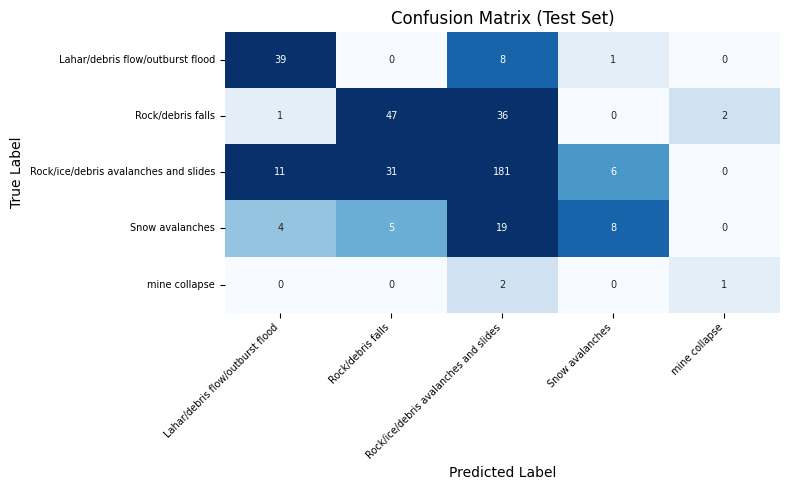

In [39]:
code_to_label_dict = {v: k for k, v in label_to_code_dict.items()}
unique_classes = sorted(list(set(y_test) | set(y_test_predict)))
tick_labels = [code_to_label_dict[code] for code in unique_classes]

cm = confusion_matrix(y_test, y_test_predict, labels=unique_classes)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 7},
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=False, vmin=0, vmax=10,
            )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7, rotation=0)
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

#### Supervised Clustering On Feature Sets, all Columns: Subtype Atleast 50 Samples

In [72]:
siamese_df_filt = siamese_features_df.copy()

class_counts = siamese_df_filt['type'].value_counts()
siamese_df_filt = siamese_df_filt[siamese_df_filt['type'].isin(class_counts[class_counts >= 50].index)]
siamese_df_filt = siamese_df_filt.reset_index(drop=True)
siamese_df_filt_filt_all_columns = siamese_df_filt.copy()

siamese_df_filt = siamese_df_filt.drop(columns=['label','Eventid','associationId','type']).copy()

print(siamese_df_filt.shape)
siamese_df_filt.head(2)

(1085, 513)


,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15,embed_16,embed_17,embed_18,embed_19,embed_20,embed_21,embed_22,embed_23,embed_24,embed_25,embed_26,embed_27,embed_28,embed_29,embed_30,embed_31,embed_32,embed_33,embed_34,embed_35,embed_36,embed_37,embed_38,embed_39,embed_40,embed_41,embed_42,embed_43,embed_44,embed_45,embed_46,embed_47,embed_48,embed_49,embed_50,embed_51,embed_52,embed_53,embed_54,embed_55,embed_56,embed_57,embed_58,embed_59,embed_60,embed_61,embed_62,embed_63,embed_64,embed_65,embed_66,embed_67,embed_68,embed_69,embed_70,embed_71,embed_72,embed_73,embed_74,embed_75,embed_76,embed_77,embed_78,embed_79,embed_80,embed_81,embed_82,embed_83,embed_84,embed_85,embed_86,embed_87,embed_88,embed_89,embed_90,embed_91,embed_92,embed_93,embed_94,embed_95,embed_96,embed_97,embed_98,embed_99,embed_100,embed_101,embed_102,embed_103,embed_104,embed_105,embed_106,embed_107,embed_108,embed_109,embed_110,embed_111,embed_112,embed_113,embed_114,embed_115,embed_116,embed_117,embed_118,embed_119,embed_120,embed_121,embed_122,embed_123,embed_124,embed_125,embed_126,embed_127,embed_128,embed_129,embed_130,embed_131,embed_132,embed_133,embed_134,embed_135,embed_136,embed_137,embed_138,embed_139,embed_140,embed_141,embed_142,embed_143,embed_144,embed_145,embed_146,embed_147,embed_148,embed_149,embed_150,embed_151,embed_152,embed_153,embed_154,embed_155,embed_156,embed_157,embed_158,embed_159,embed_160,embed_161,embed_162,embed_163,embed_164,embed_165,embed_166,embed_167,embed_168,embed_169,embed_170,embed_171,embed_172,embed_173,embed_174,embed_175,embed_176,embed_177,embed_178,embed_179,embed_180,embed_181,embed_182,embed_183,embed_184,embed_185,embed_186,embed_187,embed_188,embed_189,embed_190,embed_191,embed_192,embed_193,embed_194,embed_195,embed_196,embed_197,embed_198,embed_199,embed_200,embed_201,embed_202,embed_203,embed_204,embed_205,embed_206,embed_207,embed_208,embed_209,embed_210,embed_211,embed_212,embed_213,embed_214,embed_215,embed_216,embed_217,embed_218,embed_219,embed_220,embed_221,embed_222,embed_223,embed_224,embed_225,embed_226,embed_227,embed_228,embed_229,embed_230,embed_231,embed_232,embed_233,embed_234,embed_235,embed_236,embed_237,embed_238,embed_239,embed_240,embed_241,embed_242,embed_243,embed_244,embed_245,embed_246,embed_247,embed_248,embed_249,embed_250,embed_251,embed_252,embed_253,embed_254,embed_255,embed_256,embed_257,embed_258,embed_259,embed_260,embed_261,embed_262,embed_263,embed_264,embed_265,embed_266,embed_267,embed_268,embed_269,embed_270,embed_271,embed_272,embed_273,embed_274,embed_275,embed_276,embed_277,embed_278,embed_279,embed_280,embed_281,embed_282,embed_283,embed_284,embed_285,embed_286,embed_287,embed_288,embed_289,embed_290,embed_291,embed_292,embed_293,embed_294,embed_295,embed_296,embed_297,embed_298,embed_299,embed_300,embed_301,embed_302,embed_303,embed_304,embed_305,embed_306,embed_307,embed_308,embed_309,embed_310,embed_311,embed_312,embed_313,embed_314,embed_315,embed_316,embed_317,embed_318,embed_319,embed_320,embed_321,embed_322,embed_323,embed_324,embed_325,embed_326,embed_327,embed_328,embed_329,embed_330,embed_331,embed_332,embed_333,embed_334,embed_335,embed_336,embed_337,embed_338,embed_339,embed_340,embed_341,embed_342,embed_343,embed_344,embed_345,embed_346,embed_347,embed_348,embed_349,embed_350,embed_351,embed_352,embed_353,embed_354,embed_355,embed_356,embed_357,embed_358,embed_359,embed_360,embed_361,embed_362,embed_363,embed_364,embed_365,embed_366,embed_367,embed_368,embed_369,embed_370,embed_371,embed_372,embed_373,embed_374,embed_375,embed_376,embed_377,embed_378,embed_379,embed_380,embed_381,embed_382,embed_383,embed_384,embed_385,embed_386,embed_387,embed_388,embed_389,embed_390,embed_391,embed_392,embed_393,embed_394,embed_395,embed_396,embed_397,embed_398,embed_399,embed_400,embed_401,embed_402,embed_403,embed_404,embed_405,embed_406,embed_407,embed_408,embed_409,embed_410,embed_4

In [ ]:
## Performing the Random Forest Classifier on the Data, 70% when used best params
rf_params = {
    'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5,
     'class_weight': 'balanced_subsample', 'n_jobs': -1, 'random_state': 42, 'max_features': 'sqrt'
    }

classifier, all_features, label_to_code_dict, test_dataset, train_dataset = HelperFunc.train_randomforest_on_noisebnk(siamese_df_filt, 
                                                                                                                        labelcol='subtype', 
                                                                                                                        test_size=0.3, 
                                                                                                                        standardize=False, 
                                                                                                                        plot_cm=False,
                                                                                                                        rf_params=rf_params)
X_test_index, X_test, y_test, y_test_predict = test_dataset
X_train_index, X_train, y_train, y_train_predict = train_dataset

Model Finished training on 512 features and 759 data points
Accuracy from test set: 70.5521472392638%
Accuracy from train set: 99.7364953886693%


In [48]:
## Performing the Random Forest Classifier with a CV on the Data to find best prameters compared to above
param_distributions = {
    'n_estimators': [300, 400, 500],
    'max_depth': [5, 10, 15, 20],          
    'min_samples_split': [5, 10, 15, 20],    
    'min_samples_leaf': [2, 5, 10], 
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced_subsample'] 
}

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(estimator=base_rf, param_distributions=param_distributions, n_iter=20, 
                                    cv=5, scoring='accuracy', verbose=0, random_state=42, n_jobs=-1)
print("Starting hyperparameter search...")
random_search.fit(X_train, y_train)

print(f"\nBest Cross-Validation Accuracy: {random_search.best_score_ * 100:.2f}%")
print("Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

best_rf_model = random_search.best_estimator_
cv_test_predictions = best_rf_model.predict(X_test)
cv_train_predictions = best_rf_model.predict(X_train)

print(f"Final Train Accuracy: {accuracy_score(y_train, cv_train_predictions) * 100:.2f}%")
print(f"Final Test Accuracy: {accuracy_score(y_test, cv_test_predictions) * 100:.2f}%")

Starting hyperparameter search...

Best Cross-Validation Accuracy: 70.23%
Best Parameters Found:
  n_estimators: 300
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 20
  class_weight: balanced_subsample
Final Train Accuracy: 99.74%
Final Test Accuracy: 70.55%


In [ ]:
## 58% balanced when used best params
train_accuracy = accuracy_score(y_train, y_train_predict)
test_accuracy = accuracy_score(y_test, y_test_predict)
bal_acc = balanced_accuracy_score(y_test, y_test_predict)
macro_f1 = f1_score(y_test, y_test_predict, average='macro')

print(f"Accuracy from train set: {train_accuracy:.3f}")
print(f"Accuracy from test set: {test_accuracy:.3f}")
print(f"Balanced Accuracy: {bal_acc * 100:.2f}%")
print(f"Macro F1-Score:    {macro_f1:.4f}")

Accuracy from train set: 0.997
Accuracy from test set: 0.706
Balanced Accuracy: 58.13%
Macro F1-Score:    0.6117


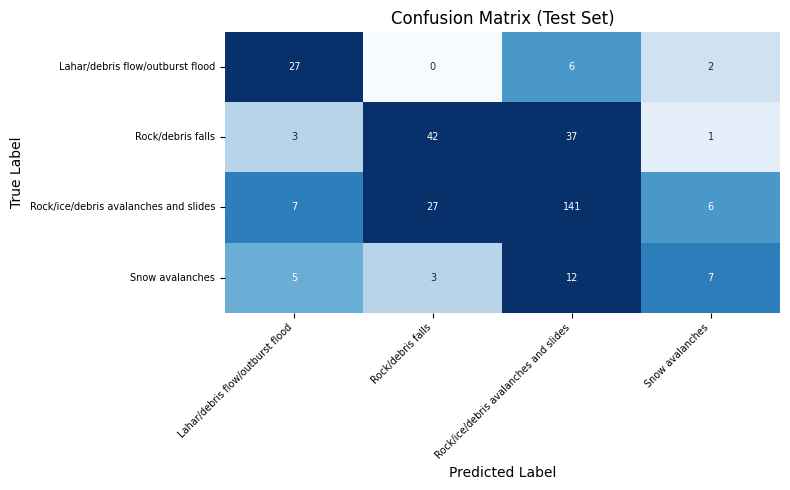

In [50]:
code_to_label_dict = {v: k for k, v in label_to_code_dict.items()}
unique_classes = sorted(list(set(y_test) | set(y_test_predict)))
tick_labels = [code_to_label_dict[code] for code in unique_classes]

cm = confusion_matrix(y_test, y_test_predict, labels=unique_classes)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 7},
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=False, vmin=0, vmax=10,
            )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7, rotation=0)
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

#### Supervised Clustering On Feature Sets, all Columns: must have atleast 50 samples per 'type'

In [51]:
siamese_df_filt = siamese_features_df.copy()

class_counts = siamese_df_filt['type'].value_counts()
siamese_df_filt = siamese_df_filt[siamese_df_filt['type'].isin(class_counts[class_counts >= 50].index)]
siamese_df_filt = siamese_df_filt.reset_index(drop=True)
siamese_df_filt_filt_all_columns = siamese_df_filt.copy()

siamese_df_filt = siamese_df_filt.drop(columns=['label','Eventid','subtype','associationId']).copy()

print(siamese_df_filt.shape)
siamese_df_filt.head(2)

(1085, 513)


,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15,embed_16,embed_17,embed_18,embed_19,embed_20,embed_21,embed_22,embed_23,embed_24,embed_25,embed_26,embed_27,embed_28,embed_29,embed_30,embed_31,embed_32,embed_33,embed_34,embed_35,embed_36,embed_37,embed_38,embed_39,embed_40,embed_41,embed_42,embed_43,embed_44,embed_45,embed_46,embed_47,embed_48,embed_49,embed_50,embed_51,embed_52,embed_53,embed_54,embed_55,embed_56,embed_57,embed_58,embed_59,embed_60,embed_61,embed_62,embed_63,embed_64,embed_65,embed_66,embed_67,embed_68,embed_69,embed_70,embed_71,embed_72,embed_73,embed_74,embed_75,embed_76,embed_77,embed_78,embed_79,embed_80,embed_81,embed_82,embed_83,embed_84,embed_85,embed_86,embed_87,embed_88,embed_89,embed_90,embed_91,embed_92,embed_93,embed_94,embed_95,embed_96,embed_97,embed_98,embed_99,embed_100,embed_101,embed_102,embed_103,embed_104,embed_105,embed_106,embed_107,embed_108,embed_109,embed_110,embed_111,embed_112,embed_113,embed_114,embed_115,embed_116,embed_117,embed_118,embed_119,embed_120,embed_121,embed_122,embed_123,embed_124,embed_125,embed_126,embed_127,embed_128,embed_129,embed_130,embed_131,embed_132,embed_133,embed_134,embed_135,embed_136,embed_137,embed_138,embed_139,embed_140,embed_141,embed_142,embed_143,embed_144,embed_145,embed_146,embed_147,embed_148,embed_149,embed_150,embed_151,embed_152,embed_153,embed_154,embed_155,embed_156,embed_157,embed_158,embed_159,embed_160,embed_161,embed_162,embed_163,embed_164,embed_165,embed_166,embed_167,embed_168,embed_169,embed_170,embed_171,embed_172,embed_173,embed_174,embed_175,embed_176,embed_177,embed_178,embed_179,embed_180,embed_181,embed_182,embed_183,embed_184,embed_185,embed_186,embed_187,embed_188,embed_189,embed_190,embed_191,embed_192,embed_193,embed_194,embed_195,embed_196,embed_197,embed_198,embed_199,embed_200,embed_201,embed_202,embed_203,embed_204,embed_205,embed_206,embed_207,embed_208,embed_209,embed_210,embed_211,embed_212,embed_213,embed_214,embed_215,embed_216,embed_217,embed_218,embed_219,embed_220,embed_221,embed_222,embed_223,embed_224,embed_225,embed_226,embed_227,embed_228,embed_229,embed_230,embed_231,embed_232,embed_233,embed_234,embed_235,embed_236,embed_237,embed_238,embed_239,embed_240,embed_241,embed_242,embed_243,embed_244,embed_245,embed_246,embed_247,embed_248,embed_249,embed_250,embed_251,embed_252,embed_253,embed_254,embed_255,embed_256,embed_257,embed_258,embed_259,embed_260,embed_261,embed_262,embed_263,embed_264,embed_265,embed_266,embed_267,embed_268,embed_269,embed_270,embed_271,embed_272,embed_273,embed_274,embed_275,embed_276,embed_277,embed_278,embed_279,embed_280,embed_281,embed_282,embed_283,embed_284,embed_285,embed_286,embed_287,embed_288,embed_289,embed_290,embed_291,embed_292,embed_293,embed_294,embed_295,embed_296,embed_297,embed_298,embed_299,embed_300,embed_301,embed_302,embed_303,embed_304,embed_305,embed_306,embed_307,embed_308,embed_309,embed_310,embed_311,embed_312,embed_313,embed_314,embed_315,embed_316,embed_317,embed_318,embed_319,embed_320,embed_321,embed_322,embed_323,embed_324,embed_325,embed_326,embed_327,embed_328,embed_329,embed_330,embed_331,embed_332,embed_333,embed_334,embed_335,embed_336,embed_337,embed_338,embed_339,embed_340,embed_341,embed_342,embed_343,embed_344,embed_345,embed_346,embed_347,embed_348,embed_349,embed_350,embed_351,embed_352,embed_353,embed_354,embed_355,embed_356,embed_357,embed_358,embed_359,embed_360,embed_361,embed_362,embed_363,embed_364,embed_365,embed_366,embed_367,embed_368,embed_369,embed_370,embed_371,embed_372,embed_373,embed_374,embed_375,embed_376,embed_377,embed_378,embed_379,embed_380,embed_381,embed_382,embed_383,embed_384,embed_385,embed_386,embed_387,embed_388,embed_389,embed_390,embed_391,embed_392,embed_393,embed_394,embed_395,embed_396,embed_397,embed_398,embed_399,embed_400,embed_401,embed_402,embed_403,embed_404,embed_405,embed_406,embed_407,embed_408,embed_409,embed_410,embed_4

In [52]:
siamese_df_filt['type'].value_counts()

type
rock fall                            233
rock avalanche                       176
landslide                            150
rock slide                           123
snow avalanche                       103
rock and ice avalanche               102
debris flow                           94
ice avalanche                         54
rock fall, rock and ice avalanche     50
Name: count, dtype: int64

In [54]:
## Performing the Random Forest Classifier on the Data
rf_params = {
    'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, #'max_features': 'sqrt',
     'class_weight': 'balanced_subsample', 'n_jobs': -1, 'random_state': 42
    }

classifier, all_features, label_to_code_dict, test_dataset, train_dataset = HelperFunc.train_randomforest_on_noisebnk(siamese_df_filt, 
                                                                                                                        labelcol='type', 
                                                                                                                        test_size=0.3, 
                                                                                                                        standardize=False, 
                                                                                                                        plot_cm=False,
                                                                                                                        rf_params=rf_params)
X_test_index, X_test, y_test, y_test_predict = test_dataset
X_train_index, X_train, y_train, y_train_predict = train_dataset

Model Finished training on 512 features and 759 data points
Accuracy from test set: 50.306748466257666%
Accuracy from train set: 94.59815546772069%


In [55]:
## Performing the Random Forest Classifier with a CV on the Data to find best prameters compared to above
## Updating the parameters as there are more number of samples per class
param_distributions = {
    'n_estimators': [300, 400, 500],
    'max_depth': [10, 15, 20],          
    'min_samples_split': [5, 10, 15, 20],    
    'min_samples_leaf': [3, 5, 10, 15], 
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced_subsample'] 
}

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(estimator=base_rf, param_distributions=param_distributions, n_iter=20, 
                                    cv=5, scoring='accuracy', verbose=0, random_state=42, n_jobs=-1)
print("Starting hyperparameter search...")
random_search.fit(X_train, y_train)

print(f"\nBest Cross-Validation Accuracy: {random_search.best_score_ * 100:.2f}%")
print("Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

results_df = pd.DataFrame(random_search.cv_results_)
summary = results_df[['mean_test_score', 'std_test_score', 'params']]
print(summary)

best_rf_model = random_search.best_estimator_
cv_test_predictions = best_rf_model.predict(X_test)
cv_train_predictions = best_rf_model.predict(X_train)

print(f"\nFinal Train Accuracy: {accuracy_score(y_train, cv_train_predictions) * 100:.2f}%")
print(f"Final Test Accuracy: {accuracy_score(y_test, cv_test_predictions) * 100:.2f}%")

Starting hyperparameter search...

Best Cross-Validation Accuracy: 45.06%
Best Parameters Found:
  n_estimators: 300
  min_samples_split: 10
  min_samples_leaf: 3
  max_features: sqrt
  max_depth: 20
  class_weight: balanced_subsample
    mean_test_score  std_test_score  \
0          0.394057        0.056422   
1          0.421724        0.048118   
2          0.424346        0.047722   
3          0.394057        0.056422   
4          0.393996        0.037026   
5          0.424346        0.043149   
6          0.400671        0.064831   
7          0.399303        0.051732   
8          0.401943        0.054305   
9          0.450636        0.035040   
10         0.409812        0.042958   
11         0.407180        0.047582   
12         0.429575        0.032956   
13         0.390084        0.044909   
14         0.417707        0.039086   
15         0.409812        0.042958   
16         0.429575        0.040924   
17         0.415101        0.045463   
18         0.391426     

In [56]:
train_accuracy = accuracy_score(y_train, y_train_predict)
test_accuracy = accuracy_score(y_test, y_test_predict)
bal_acc = balanced_accuracy_score(y_test, y_test_predict)
macro_f1 = f1_score(y_test, y_test_predict, average='macro')

print(f"Accuracy from train set: {train_accuracy:.3f}")
print(f"Accuracy from test set: {test_accuracy:.3f}")
print(f"Balanced Accuracy: {bal_acc * 100:.2f}%")
print(f"Macro F1-Score:    {macro_f1:.4f}")

Accuracy from train set: 0.946
Accuracy from test set: 0.503
Balanced Accuracy: 44.67%
Macro F1-Score:    0.4335


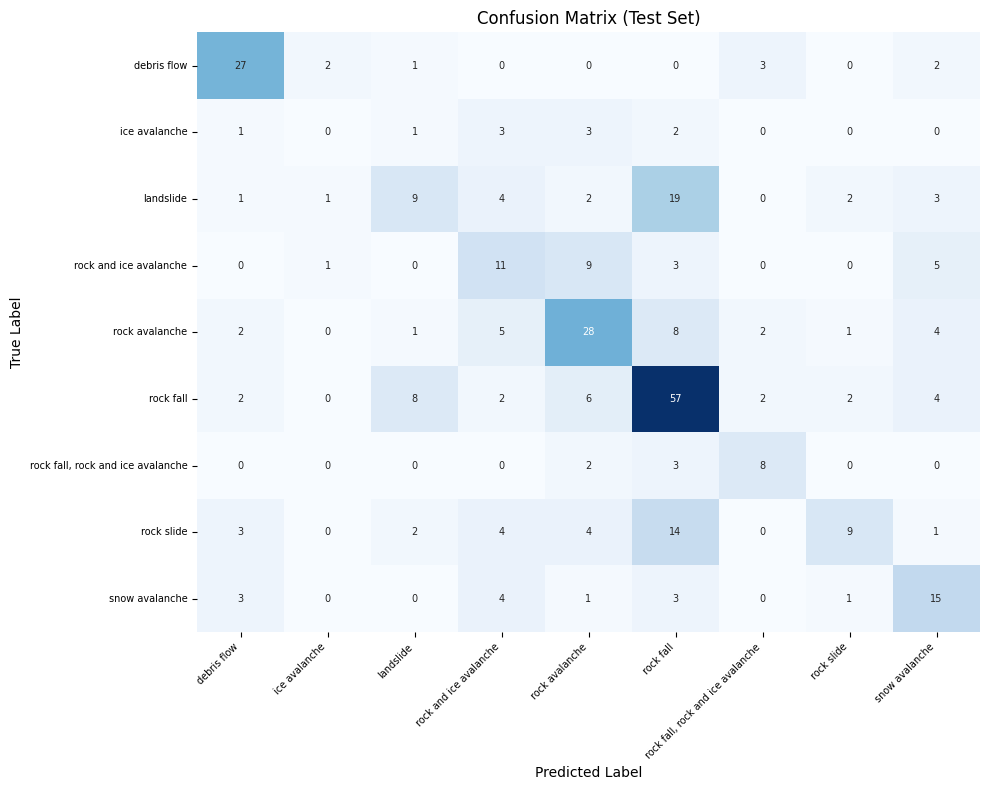

In [57]:
code_to_label_dict = {v: k for k, v in label_to_code_dict.items()}
unique_classes = sorted(list(set(y_test) | set(y_test_predict)))
tick_labels = [code_to_label_dict[code] for code in unique_classes]

cm = confusion_matrix(y_test, y_test_predict, labels=unique_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 7},
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=False, #vmin=0, vmax=10,
            )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7, rotation=0)
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

#### Supervised Clustering On PCA Reduced Columns: All Data

In [58]:
siamese_df_filt = siamese_features_df.copy()
siamese_df_filt = siamese_df_filt.drop(columns=['label','Eventid','associationId','type']).copy()

print(siamese_df_filt.shape)
siamese_df_filt.head(2)

(1337, 513)


,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15,embed_16,embed_17,embed_18,embed_19,embed_20,embed_21,embed_22,embed_23,embed_24,embed_25,embed_26,embed_27,embed_28,embed_29,embed_30,embed_31,embed_32,embed_33,embed_34,embed_35,embed_36,embed_37,embed_38,embed_39,embed_40,embed_41,embed_42,embed_43,embed_44,embed_45,embed_46,embed_47,embed_48,embed_49,embed_50,embed_51,embed_52,embed_53,embed_54,embed_55,embed_56,embed_57,embed_58,embed_59,embed_60,embed_61,embed_62,embed_63,embed_64,embed_65,embed_66,embed_67,embed_68,embed_69,embed_70,embed_71,embed_72,embed_73,embed_74,embed_75,embed_76,embed_77,embed_78,embed_79,embed_80,embed_81,embed_82,embed_83,embed_84,embed_85,embed_86,embed_87,embed_88,embed_89,embed_90,embed_91,embed_92,embed_93,embed_94,embed_95,embed_96,embed_97,embed_98,embed_99,embed_100,embed_101,embed_102,embed_103,embed_104,embed_105,embed_106,embed_107,embed_108,embed_109,embed_110,embed_111,embed_112,embed_113,embed_114,embed_115,embed_116,embed_117,embed_118,embed_119,embed_120,embed_121,embed_122,embed_123,embed_124,embed_125,embed_126,embed_127,embed_128,embed_129,embed_130,embed_131,embed_132,embed_133,embed_134,embed_135,embed_136,embed_137,embed_138,embed_139,embed_140,embed_141,embed_142,embed_143,embed_144,embed_145,embed_146,embed_147,embed_148,embed_149,embed_150,embed_151,embed_152,embed_153,embed_154,embed_155,embed_156,embed_157,embed_158,embed_159,embed_160,embed_161,embed_162,embed_163,embed_164,embed_165,embed_166,embed_167,embed_168,embed_169,embed_170,embed_171,embed_172,embed_173,embed_174,embed_175,embed_176,embed_177,embed_178,embed_179,embed_180,embed_181,embed_182,embed_183,embed_184,embed_185,embed_186,embed_187,embed_188,embed_189,embed_190,embed_191,embed_192,embed_193,embed_194,embed_195,embed_196,embed_197,embed_198,embed_199,embed_200,embed_201,embed_202,embed_203,embed_204,embed_205,embed_206,embed_207,embed_208,embed_209,embed_210,embed_211,embed_212,embed_213,embed_214,embed_215,embed_216,embed_217,embed_218,embed_219,embed_220,embed_221,embed_222,embed_223,embed_224,embed_225,embed_226,embed_227,embed_228,embed_229,embed_230,embed_231,embed_232,embed_233,embed_234,embed_235,embed_236,embed_237,embed_238,embed_239,embed_240,embed_241,embed_242,embed_243,embed_244,embed_245,embed_246,embed_247,embed_248,embed_249,embed_250,embed_251,embed_252,embed_253,embed_254,embed_255,embed_256,embed_257,embed_258,embed_259,embed_260,embed_261,embed_262,embed_263,embed_264,embed_265,embed_266,embed_267,embed_268,embed_269,embed_270,embed_271,embed_272,embed_273,embed_274,embed_275,embed_276,embed_277,embed_278,embed_279,embed_280,embed_281,embed_282,embed_283,embed_284,embed_285,embed_286,embed_287,embed_288,embed_289,embed_290,embed_291,embed_292,embed_293,embed_294,embed_295,embed_296,embed_297,embed_298,embed_299,embed_300,embed_301,embed_302,embed_303,embed_304,embed_305,embed_306,embed_307,embed_308,embed_309,embed_310,embed_311,embed_312,embed_313,embed_314,embed_315,embed_316,embed_317,embed_318,embed_319,embed_320,embed_321,embed_322,embed_323,embed_324,embed_325,embed_326,embed_327,embed_328,embed_329,embed_330,embed_331,embed_332,embed_333,embed_334,embed_335,embed_336,embed_337,embed_338,embed_339,embed_340,embed_341,embed_342,embed_343,embed_344,embed_345,embed_346,embed_347,embed_348,embed_349,embed_350,embed_351,embed_352,embed_353,embed_354,embed_355,embed_356,embed_357,embed_358,embed_359,embed_360,embed_361,embed_362,embed_363,embed_364,embed_365,embed_366,embed_367,embed_368,embed_369,embed_370,embed_371,embed_372,embed_373,embed_374,embed_375,embed_376,embed_377,embed_378,embed_379,embed_380,embed_381,embed_382,embed_383,embed_384,embed_385,embed_386,embed_387,embed_388,embed_389,embed_390,embed_391,embed_392,embed_393,embed_394,embed_395,embed_396,embed_397,embed_398,embed_399,embed_400,embed_401,embed_402,embed_403,embed_404,embed_405,embed_406,embed_407,embed_408,embed_409,embed_410,embed_4

Top 30 PCA components explain 95.01% of the total variance in the embeddings.


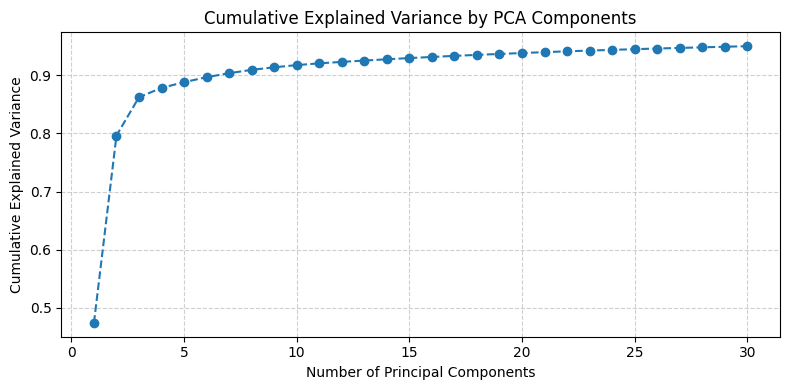

In [59]:
## Data Prep
feature_cols = [col for col in siamese_df_filt.columns if col not in ['subtype', 'label']]
X = siamese_df_filt[feature_cols]
y = siamese_df_filt['subtype'].astype('category').cat.codes

label_to_code_dict = dict(enumerate(siamese_df_filt['subtype'].astype('category').cat.categories))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, shuffle=True)

## Standardize for PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  PCA
n_components = 30 #50
pca = PCA(n_components=n_components, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Top {n_components} PCA components explain {explained_variance:.2f}% of the total variance in the embeddings.")

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [60]:
## Random Forest
rf_params = {
    'n_estimators': 500, 
    'max_depth': 15,                 
    'min_samples_split': 10,          
    'min_samples_leaf': 5,            
    'max_features': 'sqrt',        
    'class_weight': 'balanced_subsample', 
    'n_jobs': -1, 
    'random_state': 42
}
classifier = RandomForestClassifier(**rf_params)
classifier.fit(X_train_pca, y_train)

y_train_predict = classifier.predict(X_train_pca)
y_test_predict = classifier.predict(X_test_pca)

print(f"Accuracy from train set: {accuracy_score(y_train, y_train_predict) * 100:.2f}%")
print(f"Accuracy from test set: {accuracy_score(y_test, y_test_predict) * 100:.2f}%")

Accuracy from train set: 97.88%
Accuracy from test set: 73.27%


In [61]:
train_accuracy = accuracy_score(y_train, y_train_predict)
test_accuracy = accuracy_score(y_test, y_test_predict)
bal_acc = balanced_accuracy_score(y_test, y_test_predict)
macro_f1 = f1_score(y_test, y_test_predict, average='macro')

print(f"Accuracy from train set: {train_accuracy:.3f}")
print(f"Accuracy from test set: {test_accuracy:.3f}")
print(f"Balanced Accuracy: {bal_acc * 100:.2f}%")
print(f"Macro F1-Score:    {macro_f1:.4f}")

Accuracy from train set: 0.979
Accuracy from test set: 0.733
Balanced Accuracy: 54.51%
Macro F1-Score:    0.5853


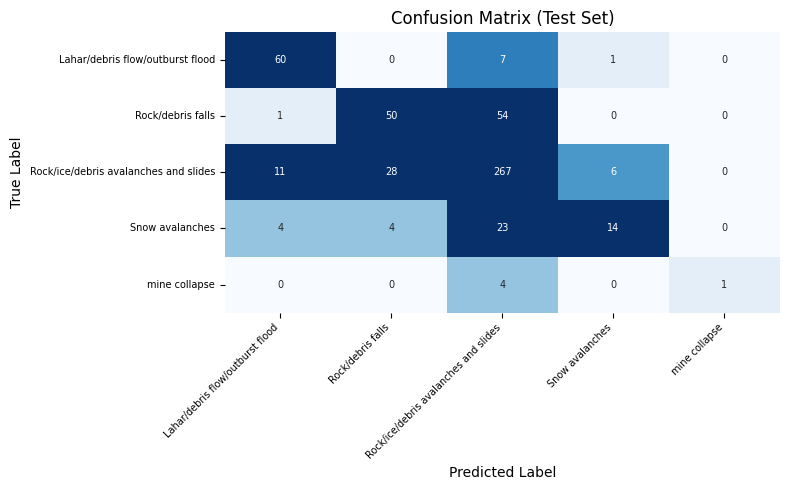

In [62]:
code_to_label_dict = {v: k for k, v in label_to_code_dict.items()}
unique_classes = sorted(list(set(y_test) | set(y_test_predict)))
tick_labels = [label_to_code_dict[code] for code in unique_classes]

cm = confusion_matrix(y_test, y_test_predict, labels=unique_classes)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 7},
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=False, vmin=0, vmax=10,
            )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7, rotation=0)
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

#### Supervised Clustering On PCA Reduced Columns: Subtype Atleast 50 Samples

In [63]:
siamese_df_filt = siamese_features_df.copy()

class_counts = siamese_df_filt['type'].value_counts()
siamese_df_filt = siamese_df_filt[siamese_df_filt['type'].isin(class_counts[class_counts >= 50].index)]
siamese_df_filt = siamese_df_filt.reset_index(drop=True)

siamese_df_filt = siamese_df_filt.drop(columns=['label','Eventid','associationId','type']).copy()

print(siamese_df_filt.shape)
siamese_df_filt.head(2)

(1085, 513)


,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15,embed_16,embed_17,embed_18,embed_19,embed_20,embed_21,embed_22,embed_23,embed_24,embed_25,embed_26,embed_27,embed_28,embed_29,embed_30,embed_31,embed_32,embed_33,embed_34,embed_35,embed_36,embed_37,embed_38,embed_39,embed_40,embed_41,embed_42,embed_43,embed_44,embed_45,embed_46,embed_47,embed_48,embed_49,embed_50,embed_51,embed_52,embed_53,embed_54,embed_55,embed_56,embed_57,embed_58,embed_59,embed_60,embed_61,embed_62,embed_63,embed_64,embed_65,embed_66,embed_67,embed_68,embed_69,embed_70,embed_71,embed_72,embed_73,embed_74,embed_75,embed_76,embed_77,embed_78,embed_79,embed_80,embed_81,embed_82,embed_83,embed_84,embed_85,embed_86,embed_87,embed_88,embed_89,embed_90,embed_91,embed_92,embed_93,embed_94,embed_95,embed_96,embed_97,embed_98,embed_99,embed_100,embed_101,embed_102,embed_103,embed_104,embed_105,embed_106,embed_107,embed_108,embed_109,embed_110,embed_111,embed_112,embed_113,embed_114,embed_115,embed_116,embed_117,embed_118,embed_119,embed_120,embed_121,embed_122,embed_123,embed_124,embed_125,embed_126,embed_127,embed_128,embed_129,embed_130,embed_131,embed_132,embed_133,embed_134,embed_135,embed_136,embed_137,embed_138,embed_139,embed_140,embed_141,embed_142,embed_143,embed_144,embed_145,embed_146,embed_147,embed_148,embed_149,embed_150,embed_151,embed_152,embed_153,embed_154,embed_155,embed_156,embed_157,embed_158,embed_159,embed_160,embed_161,embed_162,embed_163,embed_164,embed_165,embed_166,embed_167,embed_168,embed_169,embed_170,embed_171,embed_172,embed_173,embed_174,embed_175,embed_176,embed_177,embed_178,embed_179,embed_180,embed_181,embed_182,embed_183,embed_184,embed_185,embed_186,embed_187,embed_188,embed_189,embed_190,embed_191,embed_192,embed_193,embed_194,embed_195,embed_196,embed_197,embed_198,embed_199,embed_200,embed_201,embed_202,embed_203,embed_204,embed_205,embed_206,embed_207,embed_208,embed_209,embed_210,embed_211,embed_212,embed_213,embed_214,embed_215,embed_216,embed_217,embed_218,embed_219,embed_220,embed_221,embed_222,embed_223,embed_224,embed_225,embed_226,embed_227,embed_228,embed_229,embed_230,embed_231,embed_232,embed_233,embed_234,embed_235,embed_236,embed_237,embed_238,embed_239,embed_240,embed_241,embed_242,embed_243,embed_244,embed_245,embed_246,embed_247,embed_248,embed_249,embed_250,embed_251,embed_252,embed_253,embed_254,embed_255,embed_256,embed_257,embed_258,embed_259,embed_260,embed_261,embed_262,embed_263,embed_264,embed_265,embed_266,embed_267,embed_268,embed_269,embed_270,embed_271,embed_272,embed_273,embed_274,embed_275,embed_276,embed_277,embed_278,embed_279,embed_280,embed_281,embed_282,embed_283,embed_284,embed_285,embed_286,embed_287,embed_288,embed_289,embed_290,embed_291,embed_292,embed_293,embed_294,embed_295,embed_296,embed_297,embed_298,embed_299,embed_300,embed_301,embed_302,embed_303,embed_304,embed_305,embed_306,embed_307,embed_308,embed_309,embed_310,embed_311,embed_312,embed_313,embed_314,embed_315,embed_316,embed_317,embed_318,embed_319,embed_320,embed_321,embed_322,embed_323,embed_324,embed_325,embed_326,embed_327,embed_328,embed_329,embed_330,embed_331,embed_332,embed_333,embed_334,embed_335,embed_336,embed_337,embed_338,embed_339,embed_340,embed_341,embed_342,embed_343,embed_344,embed_345,embed_346,embed_347,embed_348,embed_349,embed_350,embed_351,embed_352,embed_353,embed_354,embed_355,embed_356,embed_357,embed_358,embed_359,embed_360,embed_361,embed_362,embed_363,embed_364,embed_365,embed_366,embed_367,embed_368,embed_369,embed_370,embed_371,embed_372,embed_373,embed_374,embed_375,embed_376,embed_377,embed_378,embed_379,embed_380,embed_381,embed_382,embed_383,embed_384,embed_385,embed_386,embed_387,embed_388,embed_389,embed_390,embed_391,embed_392,embed_393,embed_394,embed_395,embed_396,embed_397,embed_398,embed_399,embed_400,embed_401,embed_402,embed_403,embed_404,embed_405,embed_406,embed_407,embed_408,embed_409,embed_410,embed_4

Top 30 PCA components explain 94.71% of the total variance in the embeddings.


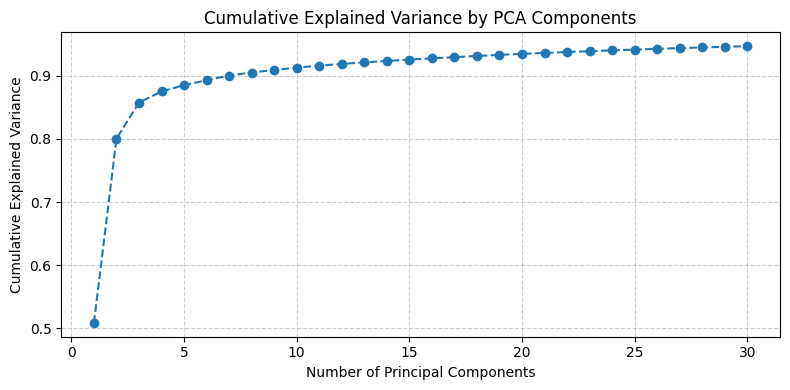

In [64]:
## Data Prep
feature_cols = [col for col in siamese_df_filt.columns if col not in ['subtype', 'label']]
X = siamese_df_filt[feature_cols]
y = siamese_df_filt['subtype'].astype('category').cat.codes

label_to_code_dict = dict(enumerate(siamese_df_filt['subtype'].astype('category').cat.categories))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

## Standardize for PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  PCA
n_components = 30 #50
pca = PCA(n_components=n_components, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Top {n_components} PCA components explain {explained_variance:.2f}% of the total variance in the embeddings.")

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [65]:
## Random Forest
rf_params = {
    'n_estimators': 500, 
    'max_depth': 15,                 
    'min_samples_split': 10,          
    'min_samples_leaf': 5,            
    'max_features': 'sqrt',        
    'class_weight': 'balanced_subsample', 
    'n_jobs': -1, 
    'random_state': 42
}
classifier = RandomForestClassifier(**rf_params)
classifier.fit(X_train_pca, y_train)

y_train_predict = classifier.predict(X_train_pca)
y_test_predict = classifier.predict(X_test_pca)

print(f"Accuracy from train set: {accuracy_score(y_train, y_train_predict) * 100:.2f}%")
print(f"Accuracy from test set: {accuracy_score(y_test, y_test_predict) * 100:.2f}%")

Accuracy from train set: 98.02%
Accuracy from test set: 69.94%


In [66]:
train_accuracy = accuracy_score(y_train, y_train_predict)
test_accuracy = accuracy_score(y_test, y_test_predict)
bal_acc = balanced_accuracy_score(y_test, y_test_predict)
macro_f1 = f1_score(y_test, y_test_predict, average='macro')

print(f"Accuracy from train set: {train_accuracy:.3f}")
print(f"Accuracy from test set: {test_accuracy:.3f}")
print(f"Balanced Accuracy: {bal_acc * 100:.2f}%")
print(f"Macro F1-Score:    {macro_f1:.4f}")

Accuracy from train set: 0.980
Accuracy from test set: 0.699
Balanced Accuracy: 59.55%
Macro F1-Score:    0.6190


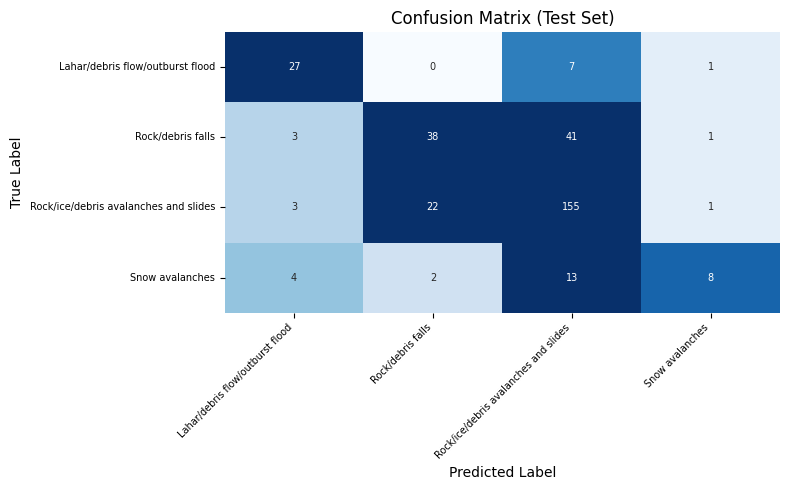

In [67]:
code_to_label_dict = {v: k for k, v in label_to_code_dict.items()}
unique_classes = sorted(list(set(y_test) | set(y_test_predict)))
tick_labels = [label_to_code_dict[code] for code in unique_classes]

cm = confusion_matrix(y_test, y_test_predict, labels=unique_classes)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 7},
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=False, vmin=0, vmax=10,
            )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7, rotation=0)
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

#### Supervised Clustering On PCA Reduced Columns: must have atleast 50 samples per 'type'

In [69]:
siamese_df_filt = siamese_features_df.copy()

class_counts = siamese_df_filt['type'].value_counts()
siamese_df_filt = siamese_df_filt[siamese_df_filt['type'].isin(class_counts[class_counts >= 50].index)]
siamese_df_filt = siamese_df_filt.reset_index(drop=True)
siamese_df_filt_filt_all_columns = siamese_df_filt.copy()

siamese_df_filt = siamese_df_filt.drop(columns=['label','Eventid','associationId','subtype']).copy()

print(siamese_df_filt.shape)
siamese_df_filt.head(2)


(1085, 513)


,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15,embed_16,embed_17,embed_18,embed_19,embed_20,embed_21,embed_22,embed_23,embed_24,embed_25,embed_26,embed_27,embed_28,embed_29,embed_30,embed_31,embed_32,embed_33,embed_34,embed_35,embed_36,embed_37,embed_38,embed_39,embed_40,embed_41,embed_42,embed_43,embed_44,embed_45,embed_46,embed_47,embed_48,embed_49,embed_50,embed_51,embed_52,embed_53,embed_54,embed_55,embed_56,embed_57,embed_58,embed_59,embed_60,embed_61,embed_62,embed_63,embed_64,embed_65,embed_66,embed_67,embed_68,embed_69,embed_70,embed_71,embed_72,embed_73,embed_74,embed_75,embed_76,embed_77,embed_78,embed_79,embed_80,embed_81,embed_82,embed_83,embed_84,embed_85,embed_86,embed_87,embed_88,embed_89,embed_90,embed_91,embed_92,embed_93,embed_94,embed_95,embed_96,embed_97,embed_98,embed_99,embed_100,embed_101,embed_102,embed_103,embed_104,embed_105,embed_106,embed_107,embed_108,embed_109,embed_110,embed_111,embed_112,embed_113,embed_114,embed_115,embed_116,embed_117,embed_118,embed_119,embed_120,embed_121,embed_122,embed_123,embed_124,embed_125,embed_126,embed_127,embed_128,embed_129,embed_130,embed_131,embed_132,embed_133,embed_134,embed_135,embed_136,embed_137,embed_138,embed_139,embed_140,embed_141,embed_142,embed_143,embed_144,embed_145,embed_146,embed_147,embed_148,embed_149,embed_150,embed_151,embed_152,embed_153,embed_154,embed_155,embed_156,embed_157,embed_158,embed_159,embed_160,embed_161,embed_162,embed_163,embed_164,embed_165,embed_166,embed_167,embed_168,embed_169,embed_170,embed_171,embed_172,embed_173,embed_174,embed_175,embed_176,embed_177,embed_178,embed_179,embed_180,embed_181,embed_182,embed_183,embed_184,embed_185,embed_186,embed_187,embed_188,embed_189,embed_190,embed_191,embed_192,embed_193,embed_194,embed_195,embed_196,embed_197,embed_198,embed_199,embed_200,embed_201,embed_202,embed_203,embed_204,embed_205,embed_206,embed_207,embed_208,embed_209,embed_210,embed_211,embed_212,embed_213,embed_214,embed_215,embed_216,embed_217,embed_218,embed_219,embed_220,embed_221,embed_222,embed_223,embed_224,embed_225,embed_226,embed_227,embed_228,embed_229,embed_230,embed_231,embed_232,embed_233,embed_234,embed_235,embed_236,embed_237,embed_238,embed_239,embed_240,embed_241,embed_242,embed_243,embed_244,embed_245,embed_246,embed_247,embed_248,embed_249,embed_250,embed_251,embed_252,embed_253,embed_254,embed_255,embed_256,embed_257,embed_258,embed_259,embed_260,embed_261,embed_262,embed_263,embed_264,embed_265,embed_266,embed_267,embed_268,embed_269,embed_270,embed_271,embed_272,embed_273,embed_274,embed_275,embed_276,embed_277,embed_278,embed_279,embed_280,embed_281,embed_282,embed_283,embed_284,embed_285,embed_286,embed_287,embed_288,embed_289,embed_290,embed_291,embed_292,embed_293,embed_294,embed_295,embed_296,embed_297,embed_298,embed_299,embed_300,embed_301,embed_302,embed_303,embed_304,embed_305,embed_306,embed_307,embed_308,embed_309,embed_310,embed_311,embed_312,embed_313,embed_314,embed_315,embed_316,embed_317,embed_318,embed_319,embed_320,embed_321,embed_322,embed_323,embed_324,embed_325,embed_326,embed_327,embed_328,embed_329,embed_330,embed_331,embed_332,embed_333,embed_334,embed_335,embed_336,embed_337,embed_338,embed_339,embed_340,embed_341,embed_342,embed_343,embed_344,embed_345,embed_346,embed_347,embed_348,embed_349,embed_350,embed_351,embed_352,embed_353,embed_354,embed_355,embed_356,embed_357,embed_358,embed_359,embed_360,embed_361,embed_362,embed_363,embed_364,embed_365,embed_366,embed_367,embed_368,embed_369,embed_370,embed_371,embed_372,embed_373,embed_374,embed_375,embed_376,embed_377,embed_378,embed_379,embed_380,embed_381,embed_382,embed_383,embed_384,embed_385,embed_386,embed_387,embed_388,embed_389,embed_390,embed_391,embed_392,embed_393,embed_394,embed_395,embed_396,embed_397,embed_398,embed_399,embed_400,embed_401,embed_402,embed_403,embed_404,embed_405,embed_406,embed_407,embed_408,embed_409,embed_410,embed_4

Top 50 PCA components explain 96.24% of the total variance in the embeddings.


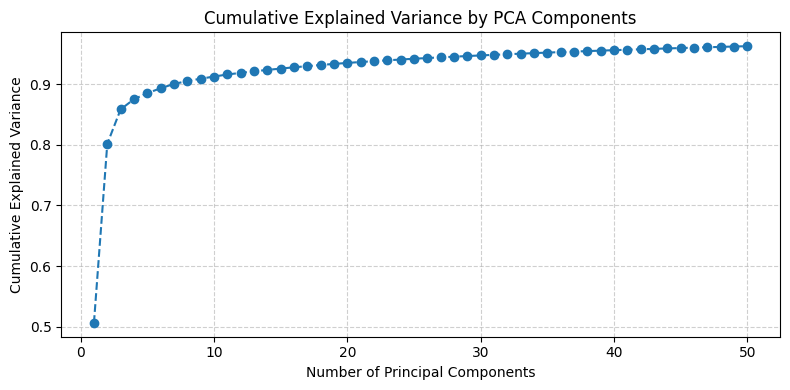

In [70]:
## Data Prep
feature_cols = [col for col in siamese_df_filt.columns if col not in ['type', 'label']]
X = siamese_df_filt[feature_cols]
y = siamese_df_filt['type'].astype('category').cat.codes

label_to_code_dict = dict(enumerate(siamese_df_filt['type'].astype('category').cat.categories))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, shuffle=True)

## Standardize for PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  PCA
n_components = 50 #10
pca = PCA(n_components=n_components, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Top {n_components} PCA components explain {explained_variance:.2f}% of the total variance in the embeddings.")

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [71]:
## Random Forest
rf_params = {
    'n_estimators': 500, 
    'max_depth': 15,                 
    'min_samples_split': 10,          
    'min_samples_leaf': 5,            
    'max_features': 'sqrt',        
    'class_weight': 'balanced_subsample', 
    'n_jobs': -1, 
    'random_state': 42
}
classifier = RandomForestClassifier(**rf_params)
classifier.fit(X_train_pca, y_train)

y_train_predict = classifier.predict(X_train_pca)
y_test_predict = classifier.predict(X_test_pca)

print(f"Accuracy from train set: {accuracy_score(y_train, y_train_predict) * 100:.2f}%")
print(f"Accuracy from test set: {accuracy_score(y_test, y_test_predict) * 100:.2f}%")

Accuracy from train set: 98.92%
Accuracy from test set: 44.93%
